In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv("Pass_Fail_Data.csv")
data.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [39]:
data = data.drop(columns = ["student_id", "attendance_pct", "homework_pct", "midterm_score"])
data.head()

,study_hours_per_week,pass
0,12,1
1,10,1
2,4,0
3,6,1
4,3,0


In [40]:
x_train = data["study_hours_per_week"].values
y_train = data["pass"].values

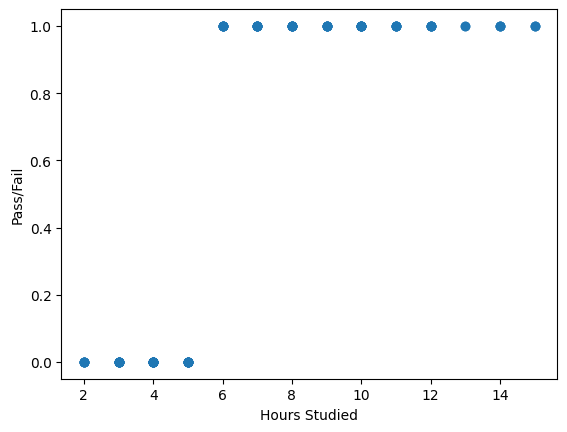

In [41]:
plt.scatter(x_train, y_train) #.plot(connects the points), this doesn't
plt.xlabel("Hours Studied")
plt.ylabel("Pass/Fail")
plt.show()

In [42]:
def predict(x, m, c):
    line = -(x * m + c)
    denominator = 1 + np.exp(line)
    y_predicted = 1 / denominator
    return y_predicted

In [43]:
def cost_function(y_train, x_train, m, c):
    y_predicted = predict(x_train, m, c)
    first_half = y_train * np.log(y_predicted) # math.log() doesn't operate on arrays
    second_half = (1 - y_train) * np.log(1 - y_predicted)
    total = first_half + second_half
    cost = -np.sum(total) / len(y_train)
    return cost

In [44]:
def gradients(y_train, x_train, m, c):
    n = len(y_train)
    
    error_term = predict(x_train, m, c) - y_train
    
    gradient_m = np.sum(error_term * x_train) / n
    gradient_c = np.sum(error_term) / n
    
    return gradient_m, gradient_c

In [45]:
def gradient_descent(y_train, x_train, m, c, learning_rate):
    
    gradient_m, gradient_c = gradients(y_train, x_train, m, c)
    
    m = m - learning_rate * gradient_m
    c = c - learning_rate * gradient_c

    return m, c

In [46]:
m = 0
c = 0
learning_rate = 0.01
epochs = 4000

for i in range(epochs):
    m, c = gradient_descent(y_train, x_train, m, c, learning_rate)
    
    if i % 200 == 0:
        print(f"Iteration: {i} Cost: {cost_function(y_train, x_train, m, c)}")
        

print(f'Final m: {m}, Final c: {c}')


Iteration: 0 Cost: 0.6502695952931629
Iteration: 200 Cost: 0.49926676548154125
Iteration: 400 Cost: 0.46431015726703273
Iteration: 600 Cost: 0.4340614307126202
Iteration: 800 Cost: 0.4077782732101268
Iteration: 1000 Cost: 0.3848275973212737
Iteration: 1200 Cost: 0.3646783386600819
Iteration: 1400 Cost: 0.3468893888449738
Iteration: 1600 Cost: 0.3310962085893441
Iteration: 1800 Cost: 0.3169980346401703
Iteration: 2000 Cost: 0.30434654056228355
Iteration: 2200 Cost: 0.29293620750212307
Iteration: 2400 Cost: 0.28259635276695766
Iteration: 2600 Cost: 0.2731846299860716
Iteration: 2800 Cost: 0.2645817745054234
Iteration: 3000 Cost: 0.25668737352510107
Iteration: 3200 Cost: 0.2494164657107333
Iteration: 3400 Cost: 0.24269680584173983
Iteration: 3600 Cost: 0.23646665998551286
Iteration: 3800 Cost: 0.23067302304708662
Final m: 0.6425750254750596, Final c: -3.327964175716028


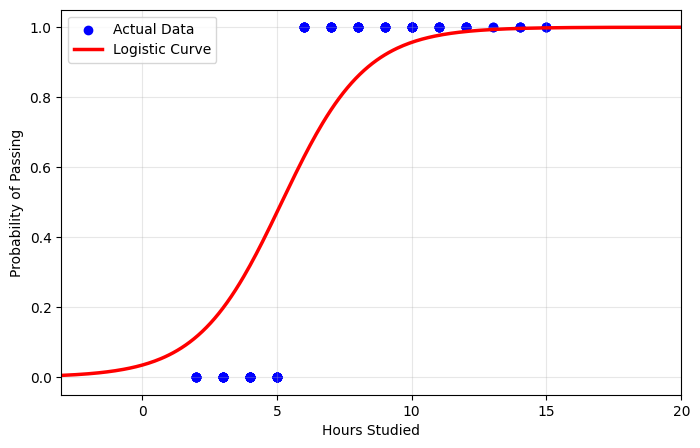

In [47]:
predictions = predict(x_train, m, c)

x_plot = np.linspace(min(x_train) - 5, max(x_train) + 5, 300)
y_plot = predict(x_plot, m, c)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color="blue", label="Actual Data")
plt.plot(x_plot, y_plot, color="red", linewidth=2.5, label="Logistic Curve")

plt.xlim(min(x_plot), max(x_plot))
plt.ylim(-0.05, 1.05)

plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [48]:
hours = float(input("How many hours did you study?: "))

prediction = predict(hours, m, c)

if(prediction >= 0.5):
    print("Pass")
else:
    print("Fail")

Pass
